# Лабораторная работа №2

In [20]:
library(tidyverse)
library(lubridate)
library(forecast)
library(tseries)
library(ARDL)
library(CausalImpact)
library(TraMineR)
library(geepack)
library(plm)
library(zoo)
library(patchwork)
library(ggplot2)

Sys.setlocale("LC_CTYPE", "C.UTF-8")

[1] "C.UTF-8"

## Часть 1: Анализ временных рядов (оперативная аналитика кофейни)

Вы работаете продуктовым аналитиком в сети кофеен. В четверг вечером ваш лид
присылает задачу: к понедельнику на планерке необходимо предложить пути развития
сети в городе. Поскольку лиду важны не скорость, а качественные гипотезы и анализ
различий, он просит вас сфокусироваться на ОДНОЙ точке (один store_id: 3, 5 или
8) и ОДНОМ продукте (Coffee или Tea), в то время как остальные категории посмотрит ваш коллега. Цель анализа: дать общую характеристику ежедневной (критичный
приоритет) и/или ежемесячной (в меньшей степени) аудитории кофейни и продукта,
а также выяснить, что влияет на динамику выручки в большей степени. Результаты важны для брейн-шторма на планерке в понедельник, поэтому важно посмотреть
данные с разных сторон, но не «увлекаться» глубиной моделирования, сфокусировавшись
на конкретных вопросах и детерминации процессов. Лид перекинул вам данные как CSVфайл и SQLite (на вопрос «Почему в этом формате???» — лид исчез, но обещал вернуться в понедельник. .. )

### Шаг 0. Выбор комбинации для анализа

In [21]:
store_id_use <- 8
product_category_use <- "Coffee"

### Упражнение 1.1. Агрегация данных до ежедневного уровня


1.  Загрузите lab2_timeseries_coffee.csv или lab2_coffee_integrat.sqlite (во втором случае работайте с отношением «timeseries_coffee»). Отфильтруйте по выбранному store_id и product_category

In [22]:
transactions_raw <- readr::read_csv("lab7_timeseries_coffee.csv", show_col_types = FALSE)
transactions = filter(transactions_raw, store_id == store_id_use & product_category == product_category_use)
print(names(transactions))
head(transactions, 5)

 [1] "transaction_id"         "transaction_date"       "transaction_time"      
 [4] "store_id"               "store_location"         "product_id"            
 [7] "product_category"       "product_type"           "product_detail"        
[10] "transaction_qty"        "unit_price"             "total_bill"            
[13] "hour_num"               "month_name"             "day_name"              
[16] "day_of_week_num"        "is_peak_hour"           "is_weekend"            
[19] "is_app_order"           "payment_success"        "payment_failure_flag"  
[22] "rating"                 "is_negative_review"     "is_constructive_review"
[25] "is_stuck_order"         "is_refund"              "prep_time_est"         
[28] "customization_flag"     "upsell_flag"            "is_new_customer"       
[31] "loyalty_eligible"       "news_shock"             "promo_eligible"        
[34] "weather_shock"          "covariate_weather"     


transaction_id,transaction_date,transaction_time,store_id,store_location,product_id,product_category,product_type,product_detail,transaction_qty,...,is_refund,prep_time_est,customization_flag,upsell_flag,is_new_customer,loyalty_eligible,news_shock,promo_eligible,weather_shock,covariate_weather
<dbl>,<date>,<time>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
55060,2023-04-01,08:28:15,8,TRZ_ForPlaza,24,Coffee,Drip coffee,Our Old Time Diner Blend,1,...,0,4.3,0,0,0,0,0,0,0,15.5
55199,2023-04-01,11:47:56,8,TRZ_ForPlaza,24,Coffee,Drip coffee,Our Old Time Diner Blend,1,...,0,3.1,0,0,0,0,0,0,0,13.7
55249,2023-04-01,12:51:09,8,TRZ_ForPlaza,24,Coffee,Drip coffee,Our Old Time Diner Blend,1,...,0,4.3,0,0,1,0,0,0,0,19.4
55265,2023-04-01,12:49:13,8,TRZ_ForPlaza,24,Coffee,Drip coffee,Our Old Time Diner Blend,1,...,0,4.2,0,1,0,0,0,0,0,15.0
55531,2023-04-01,15:52:25,8,TRZ_ForPlaza,24,Coffee,Drip coffee,Our Old Time Diner Blend,1,...,0,6.1,0,1,0,0,0,0,0,23.5



2. Сгруппируйте по transaction_date (т.е. суточная агрегация) и рассчитайте:
    - revenue = сумма total_bill
    - n_transactions = число транзакций
    - avg_ticket = средний чек
    - dau_approx = уникальные посетители (аппроксимация) → DAU
    - 2 синтетические метрики на выбор (например, avg_rating, app_order_share)

In [23]:
daily <- summarise(
    group_by(transactions, transaction_date),
    revenue = sum(total_bill),
    n_transactions = n(),
    avg_ticket = mean(total_bill),
    # В данных нет ничего похожего на идентификатор посетителя, поэтому будем использовать transaction_id
    dau_approx = n_distinct(transaction_id),
    avg_rating = mean(rating),
    app_order_share = mean(is_app_order == 1),
)
head(daily, 5)

transaction_date,revenue,n_transactions,avg_ticket,dau_approx,avg_rating,app_order_share
<date>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>
2023-01-01,427.05,87,4.908621,87,3.754023,0.4137931
2023-01-02,398.30,91,4.376923,91,3.793407,0.3626374
2023-01-03,336.40,77,4.368831,77,3.872727,0.3506494
2023-01-04,388.75,82,4.740854,82,3.846341,0.4024390
2023-01-05,320.15,77,4.157792,77,3.772727,0.3246753



3. Заполните пропущенные дни через complete() либо с помощью пакета imputeTS

In [24]:
min_date = min(daily$transaction_date)
max_date = max(daily$transaction_date)

print(min_date)
print(max_date)

all_days <- tibble(transaction_date = seq(min_date, max_date, by = "day"))
missing_days <- anti_join(all_days, daily['transaction_date'], by = "transaction_date")
missing_days # Пропущенных дней и так нет, заполнять нечего.

[1] "2023-01-01"
[1] "2023-06-30"


transaction_date
<date>


In [25]:
# Чтобы наверняка, запустим заполнение
daily <- complete(daily, transaction_date = seq(min_date, max_date, by = "day"))
daily[is.na(daily)] <- 0
head(daily, 5)

transaction_date,revenue,n_transactions,avg_ticket,dau_approx,avg_rating,app_order_share
<date>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>
2023-01-01,427.05,87,4.908621,87,3.754023,0.4137931
2023-01-02,398.30,91,4.376923,91,3.793407,0.3626374
2023-01-03,336.40,77,4.368831,77,3.872727,0.3506494
2023-01-04,388.75,82,4.740854,82,3.846341,0.4024390
2023-01-05,320.15,77,4.157792,77,3.772727,0.3246753


### Упражнение 1.2. Визуализация и STL-декомпозиция

1. Постройте график временного ряда revenue с помощью ggplot2 или R-base

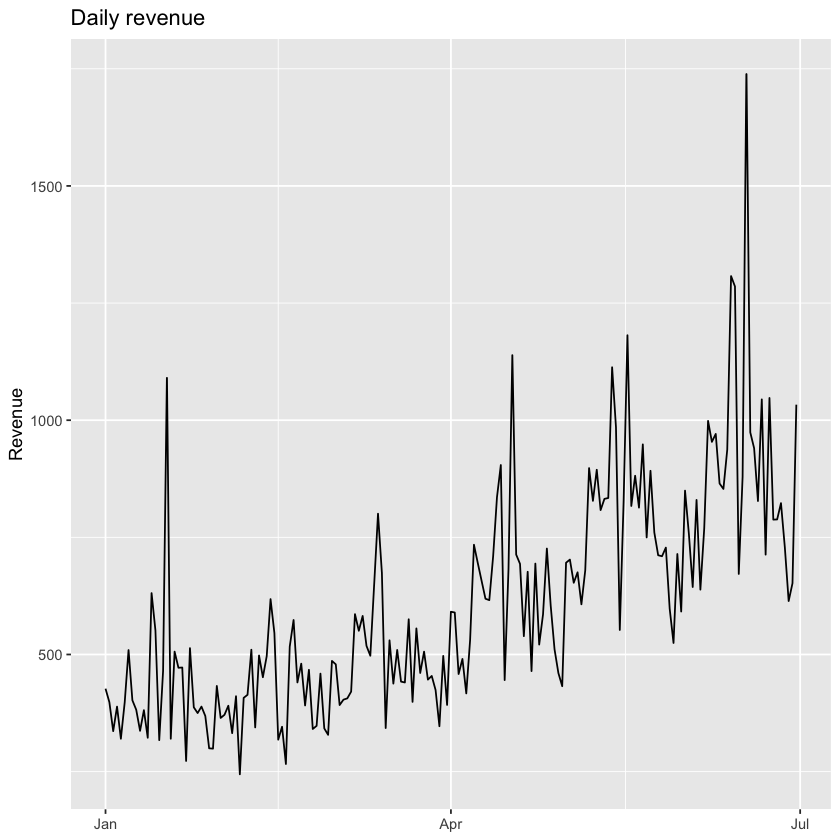

In [26]:
(
    ggplot(daily, aes(x = transaction_date, y = revenue)) +
    geom_line() +
    labs(title = "Daily revenue", x = NULL, y = "Revenue")
)

2. Выполните STL-декомпозицию

NULL
        date actual    trend   seasonal   residual
1 2023-01-01 427.05 385.9627 -10.522659  51.609992
2 2023-01-02 398.30 387.3450  -5.514562  16.469600
3 2023-01-03 336.40 388.7273  31.534953 -83.862210
4 2023-01-04 388.75 390.4814  -5.691116   3.959702
5 2023-01-05 320.15 392.2356 -28.073829 -44.011743
6 2023-01-06 397.90 395.1020   4.831935  -2.033933


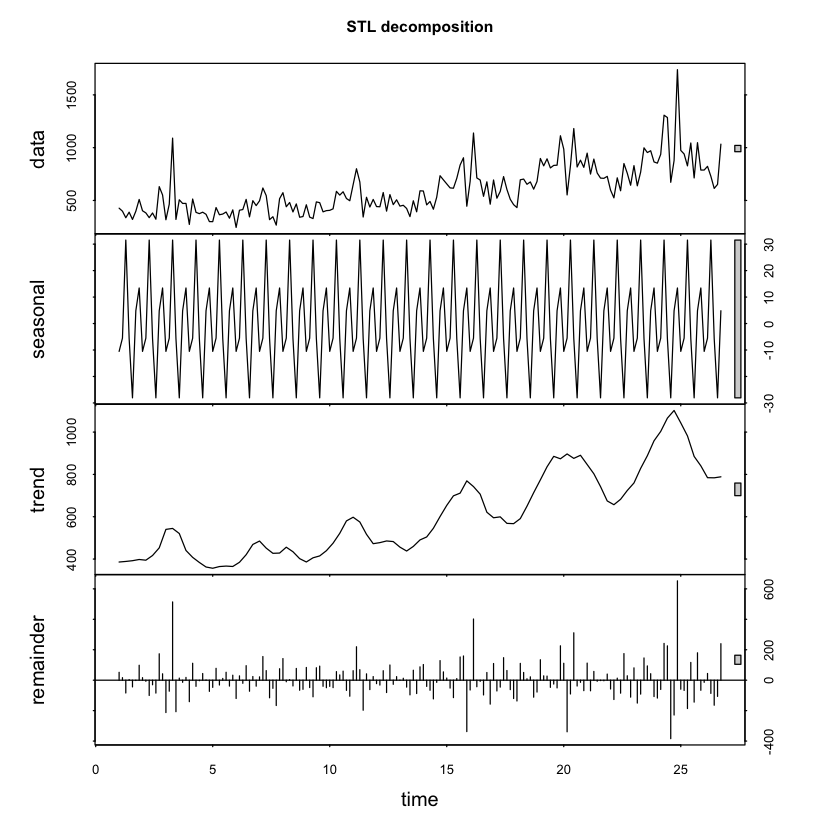

In [27]:
decomp <- stl(ts(daily$revenue, frequency = 7), s.window = "periodic")
print(plot(decomp, main = "STL decomposition"))

decomp_df <- data.frame(
    date = daily$transaction_date,
    actual = as.numeric(ts(daily$revenue, frequency = 7)),
    trend = as.numeric(decomp$time.series[, "trend"]),
    seasonal = as.numeric(decomp$time.series[, "seasonal"]),
    residual = as.numeric(decomp$time.series[, "remainder"])
)
print(head(decomp_df))

3. Визуализируйте три компоненты: тренд, сезонность, остаток в виде аккуратного информативного рисунка

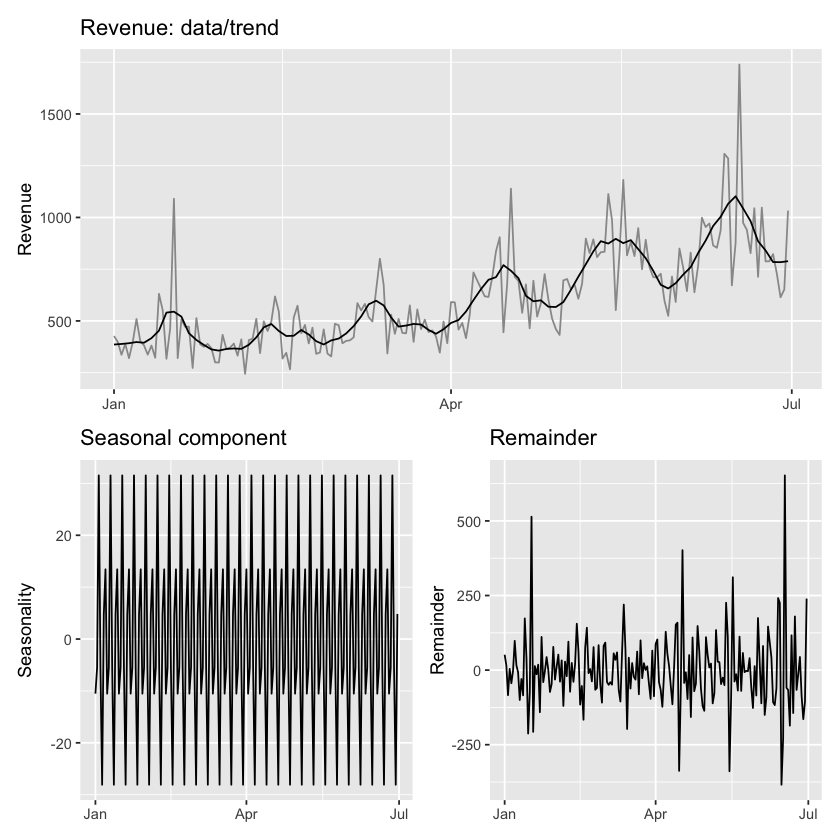

In [28]:
p1 <- ggplot(decomp_df, aes(x = date)) +
    geom_line(aes(y = actual), color = "gray60") +
    geom_line(aes(y = trend)) +
    labs(title = "Revenue: data/trend", x = NULL, y = "Revenue")

p2 <- ggplot(decomp_df, aes(x = date, y = seasonal)) +
    geom_line() +
    labs(title = "Seasonal component", x = NULL, y = "Seasonality")

p3 <- ggplot(decomp_df, aes(x = date, y = residual)) +
    geom_line() +
    labs(title = "Remainder", x = NULL, y = "Remainder")

(p1 / (p2 | p3))

4. В отчёте ответьте:
    - Есть ли видимый тренд? (растёт/падает/стабилен)
    - Какая сезонность наблюдается? (недельная, месячная)
    - Насколько велика доля остатка (шума)?

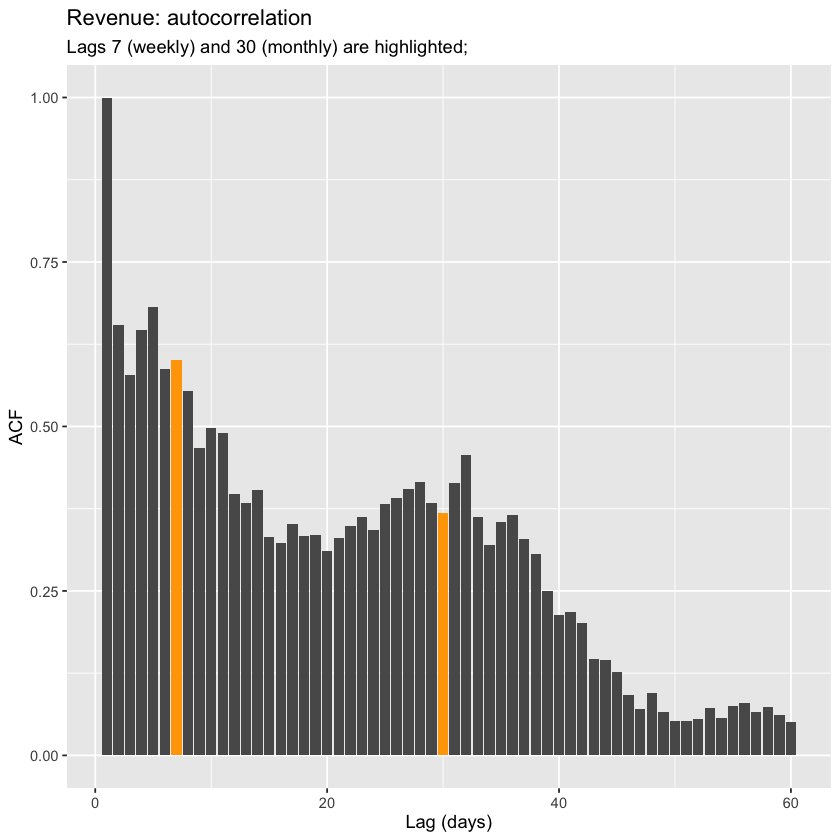

In [29]:
acf_vals <- acf(daily$revenue, lag.max = 60, plot = FALSE)
acf_df <- tibble(lag = 1:60, acf = as.numeric(acf_vals$acf[1:60]))

ggplot(acf_df, aes(x = lag, y = acf)) +
geom_col() +
geom_col(data = subset(acf_df, lag == 7), fill = "orange") +
geom_col(data = subset(acf_df, lag == 30), fill = "orange") +
labs(
    title = "Revenue: autocorrelation",
    subtitle = "Lags 7 (weekly) and 30 (monthly) are highlighted; ",
    x = "Lag (days)",
    y = "ACF"
)

In [30]:
print(sprintf("Remainder mean: %.4f", mean(decomp$time.series[, "remainder"])))
print(sprintf("Remainder std: %.4f", sd(decomp$time.series[, "remainder"])))

print(sprintf("Revenue mean: %.4f", mean(daily$revenue)))
print(sprintf("Revenue std: %.4f", sd(daily$revenue)))

[1] "Remainder mean: -0.0582"
[1] "Remainder std: 126.1066"
[1] "Revenue mean: 606.9489"
[1] "Revenue std: 237.1433"


Явно виден растущий тренд, особенно с апреля. Считаю, что даже нет необходимости проводить дополнительные тесты; из визуализации STL явно виден рост.

Сезонность наблюдается как недельная, так и месячная (пики на графике автокорелляций). Тем не менее недельная заметно преобладает. На масштабе более 40 дней, сезонность вовсе практически не наблюдается.

Доля шума достаточно велика. При масштабе данных около 500-1000, шум в отдельных наблюдениях достигает 250-500, что сравнимо со значениями временного ряда. Это подтверждется и рассчитанными метриками: хотя средний шум и близок к нулю, его стандартное отклонение превышает 126 при том, что среднее значение временного ряда - 606 со стандартным отклонением 237.

### Упражнение 1.3. Проверка стационарности

1. Проведите тест ADF, KPSS, PP. Сделайте сводную таблицу по результатам анализа

In [31]:
adf_res <- adf.test(daily$revenue)
kpss_res <- kpss.test(daily$revenue)
pp_res <- pp.test(daily$revenue)

print(adf_res)
print(kpss_res)
print(pp_res)

tibble(
    test = c("ADF", "KPSS", "PP"),
    statistic = c(adf_res$statistic, kpss_res$statistic, pp_res$statistic),
    p_value = c(adf_res$p.value, kpss_res$p.value, pp_res$p.value)
)

Warning message in kpss.test(daily$revenue):
“p-value smaller than printed p-value”
Warning message in pp.test(daily$revenue):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  daily$revenue
Dickey-Fuller = -2.8451, Lag order = 5, p-value = 0.223
alternative hypothesis: stationary


	KPSS Test for Level Stationarity

data:  daily$revenue
KPSS Level = 2.8423, Truncation lag parameter = 4, p-value = 0.01


	Phillips-Perron Unit Root Test

data:  daily$revenue
Dickey-Fuller Z(alpha) = -142.95, Truncation lag parameter = 4, p-value
= 0.01
alternative hypothesis: stationary



test,statistic,p_value
<chr>,<dbl>,<dbl>
ADF,-2.845094,0.2229842
KPSS,2.842310,0.0100000
PP,-142.949177,0.0100000


2. Дополните исследование стационарности выгрузкой auto.arima

In [32]:
auto.arima(daily$revenue, seasonal = TRUE, stepwise = FALSE, approximation = FALSE)

Series: daily$revenue 
ARIMA(0,1,5) 

Coefficients:
          ma1      ma2     ma3     ma4      ma5
      -0.7469  -0.1807  0.1757  0.2838  -0.1639
s.e.   0.0738   0.0888  0.0902  0.0976   0.0815

sigma^2 = 22520:  log likelihood = -1155.5
AIC=2322.99   AICc=2323.48   BIC=2342.15

3. Сделайте вывод о необходимости дифференцирования
4. В отчёте ответьте:
    - Какой вывод по ADF? KPSS? PP?
    - Нужно ли дифференцирование? Почему?

ADF: p-value = 0.22 > 0.05. Следовательно, нулевая гипотеза о наличии единичного корна (нестационарности ряда) принимается на уровне доверия 95%. Ряд не станционарен.

KPSS: p-value = 0.01 < 0.05. Следовательно, нулевая гипотеза о стационарности ряда отвергается на уровне доверия 95%. Ряд не станционарен.

PP: p-value = 0.01 < 0.05.  Следовательно, нулевая гипотеза о наличии единичного корна (нестационарности ряда) отвергается на уровне доверия 95%. Ряд станционарен.

В целом, ряд можно считать нестационарным. Тем не менее интересно, что один из тестов отвергает эту гипотезу.

Таким образом, к ряду следует применить дифференцирование, чтобы сделать его стационарным. Причем из коэффициентов auto-arima (0, 1, 5) следует, что дифференцировать нужно один раз.

In [33]:
adf_res <- adf.test(diff(daily$revenue))
kpss_res <- kpss.test(diff(daily$revenue))
pp_res <- pp.test(diff(daily$revenue))

tibble(
    test = c("ADF", "KPSS", "PP"),
    statistic = c(adf_res$statistic, kpss_res$statistic, pp_res$statistic),
    p_value = c(adf_res$p.value, kpss_res$p.value, pp_res$p.value)
)

Warning message in adf.test(diff(daily$revenue)):
“p-value smaller than printed p-value”
Warning message in kpss.test(diff(daily$revenue)):
“p-value greater than printed p-value”
Warning message in pp.test(diff(daily$revenue)):
“p-value smaller than printed p-value”


test,statistic,p_value
<chr>,<dbl>,<dbl>
ADF,-7.37966446,0.01
KPSS,0.02530227,0.10
PP,-195.41241008,0.01


На самом деле, после дифференцирования все 3 теста указывают, что ряд стал стационарным.

### Упражнение 1.4. Моделирование: ARDL ИЛИ VAR

1. Оцените модель через auto_ardl(x, data=..., max_order=3)
ИЛИ через VARselect() + VAR() для VAR-модели

In [34]:
ardl_model <- auto_ardl(
    revenue ~ n_transactions + avg_ticket + dau_approx + avg_rating + app_order_share,
    data = daily,
    max_order = 3
)
summary(ardl_model$best_model)


Time series regression with "ts" data:
Start = 4, End = 181

Call:
dynlm::dynlm(formula = full_formula, data = data, start = start, 
    end = end)

Residuals:
    Min      1Q  Median      3Q     Max 
-337.98  -13.88    0.67   12.51  289.98 

Coefficients: (2 not defined because of singularities)
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)           -556.26395  186.76723  -2.978  0.00333 ** 
L(revenue, 1)            0.14760    0.07656   1.928  0.05557 .  
n_transactions           5.12651    0.18552  27.634  < 2e-16 ***
L(n_transactions, 1)    -0.71639    0.43800  -1.636  0.10382    
L(n_transactions, 2)    -0.21272    0.19546  -1.088  0.27804    
L(n_transactions, 3)     0.53319    0.18962   2.812  0.00552 ** 
avg_ticket              83.28935    2.29850  36.236  < 2e-16 ***
L(avg_ticket, 1)        -9.44343    6.78824  -1.391  0.16604    
dau_approx                    NA         NA      NA       NA    
L(dau_approx, 1)              NA         NA      NA

2. Проверьте остатки (ACF, Ljung-Box тест)

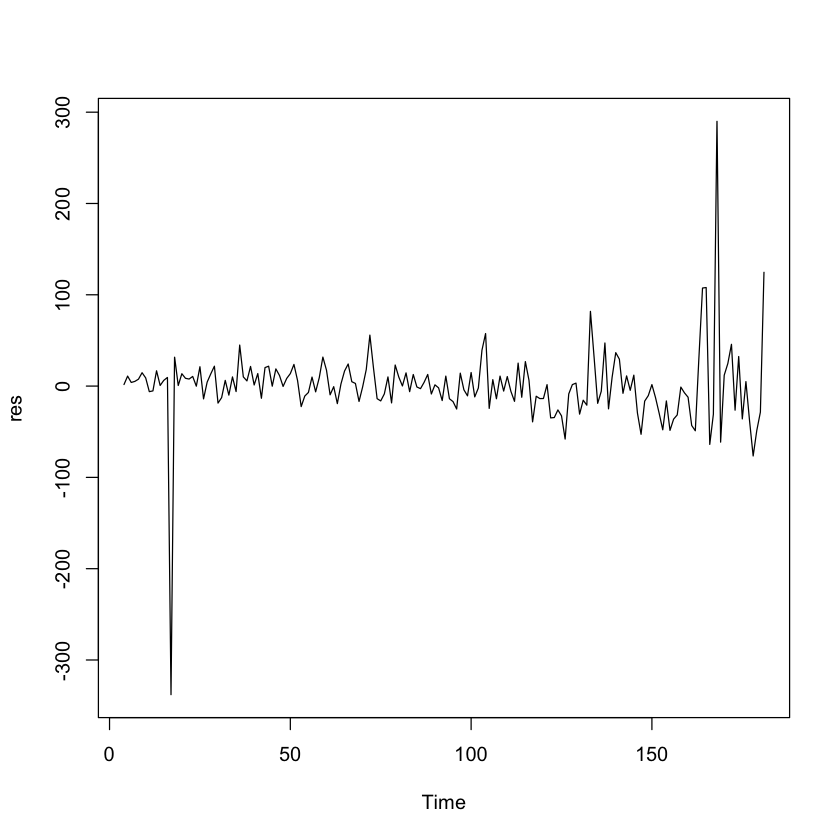

In [35]:
res <- residuals(ardl_model$best_model)
plot(res)

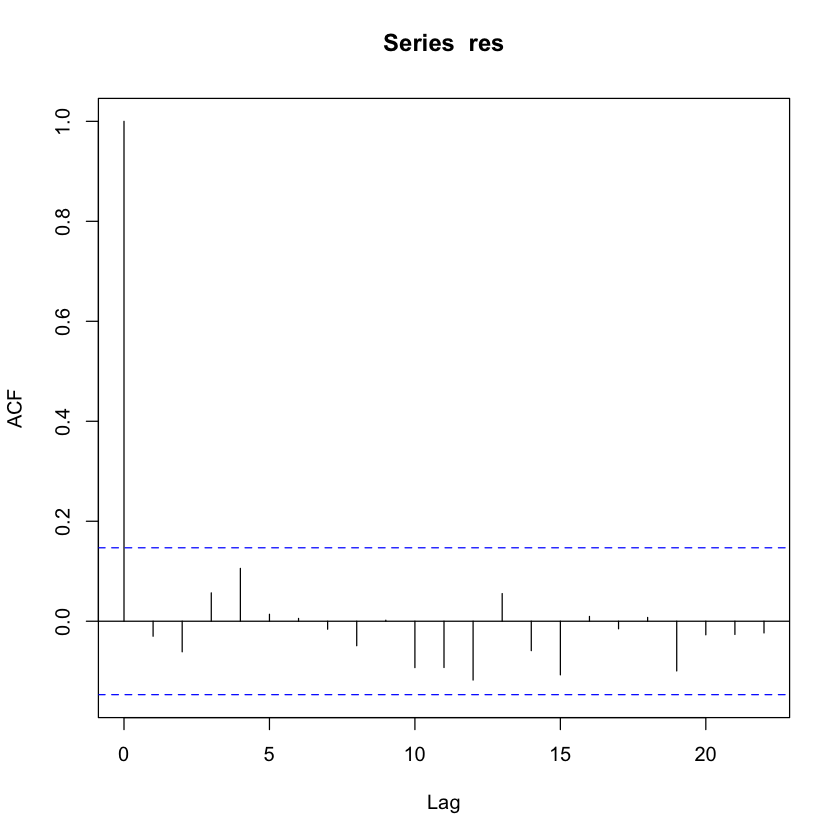

In [36]:
plot(acf(res))

In [37]:
Box.test(res, lag = 7, type = "Ljung")


	Box-Ljung test

data:  res
X-squared = 3.579, df = 7, p-value = 0.8268


Остатки в целом достаточно маленькие: близки к нулю с небольшим отклонением. Есть несколько выбросов (отрицательный в начале, положительные в конце), но в целом остатки достаточно "ровные".

ACF также подтверждает, что в остатках нет значимых автокорреляций: все значения близки к нулю и не выходят за границы доверительного интервала.

Наконец, это подтверждает и Ljung-Box тест. Большой p_value (0.83) указывает, что нулевая гипотеза об отсутствии автокорреляций не отвергается.

Таким образом, остатки не имеют явной структуры, в связи с чем модель можно считать хорошей.

3. Интерпретируйте 1–2 значимых коэффициента на языке продукта

In [38]:
summary(ardl_model$best_model)$coefficients

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),-556.2639460,186.76723179,-2.9783808,3.332273e-03
"L(revenue, 1)",0.1475972,0.07655774,1.9279195,5.557205e-02
n_transactions,5.1265128,0.18551753,27.6335769,5.410220e-64
"L(n_transactions, 1)",-0.7163936,0.43800259,-1.6355922,1.038197e-01
"L(n_transactions, 2)",-0.2127183,0.19545765,-1.0883088,2.780364e-01
"L(n_transactions, 3)",0.5331908,0.18962126,2.8118727,5.519134e-03
avg_ticket,83.2893462,2.29849937,36.2364015,9.473214e-81
"L(avg_ticket, 1)",-9.4434274,6.78824205,-1.3911448,1.660432e-01
avg_rating,49.0969907,46.85358172,1.0478813,2.962166e-01
app_order_share,37.4862062,56.32081918,0.6655835,5.066011e-01


Наиболее значимые коэффициенты - те, чей p-value минимален: это означает, что нулевая гипотеза о том, что коэффициент равен нулю, отвергается. Таким образом, наиболее значимыми являются коээфициент 5.12 при переменной n_transactions и 83.29 при переменной avg_ticket. И это вполне ожидаемый результат, так как эти переменные буквально являются составляющими целевой revenue: доход состоит из среднего чека, умноженного на количество чеков.

Коэффициент 5.12 означает, что каждый дополнительный чек приносит компании в среднем 5.12 единиц выручки, причем отклонение (std. error) этого значения достаточно невелико: модель уверена в этом коэффициенте.

Аналогично, коэффициент 83.29 указывает, что увеличение среднего чека на единицу в среднем приводит к увеличению дохода на 83.29, при том, что эта оценка имеет ошибку в 2.3 единицы.

### Упражнение 1.5. CausalImpact: оценка причинного эффекта


1. Выберите ОДИН сценарий вмешательства:
    - Запуск программы лояльности (2023-06-15) → зависимая: revenue
    - Негативный новостной фон (2023-05-20 — 2023-05-27) → зависимая: avg_rating
    - Акция «2 по цене 1» на кофе (2023-06-01 — 2023-06-07) → зависимая: revenue
    - Погодный шок (2023-05-25 — 2023-05-27) → зависимая: dau_approx
2. Задайте периоды: pre_period и post_period
3. Запустите модель: CausalImpact(impact_xts, pre_period, post_period)

In [39]:
# Запуск программы лояльности (2023-06-15) → зависимая: revenue
intervention_date <- as.Date("2023-06-15")

pre_period <- c(min(daily$transaction_date), intervention_date - 1)
post_period <- c(intervention_date, max(daily$transaction_date))

impact_data <- cbind(revenue = daily$revenue)
impact_xts <- xts(impact_data, order.by = daily$transaction_date)
impact <- CausalImpact(impact_xts, pre_period, post_period)
summary(impact)

Posterior inference {CausalImpact}

                         Average        Cumulative    
Actual                   891            14263         
Prediction (s.d.)        824 (57)       13184 (910)   
95% CI                   [722, 932]     [11555, 14920]
                                                      
Absolute effect (s.d.)   67 (57)        1079 (910)    
95% CI                   [-41, 169]     [-656, 2708]  
                                                      
Relative effect (s.d.)   8.6% (7.5%)    8.6% (7.5%)   
95% CI                   [-4.4%, 23%]   [-4.4%, 23%]  

Posterior tail-area probability p:   0.13111
Posterior probability of an effect:  87%

For more details, type: summary(impact, "report")



In [40]:
summary(impact, "report")

Analysis report {CausalImpact}


During the post-intervention period, the response variable had an average value of approx. 891.46. In the absence of an intervention, we would have expected an average response of 823.99. The 95% interval of this counterfactual prediction is [722.22, 932.48]. Subtracting this prediction from the observed response yields an estimate of the causal effect the intervention had on the response variable. This effect is 67.46 with a 95% interval of [-41.03, 169.24]. For a discussion of the significance of this effect, see below.

Summing up the individual data points during the post-intervention period (which can only sometimes be meaningfully interpreted), the response variable had an overall value of 14.26K. Had the intervention not taken place, we would have expected a sum of 13.18K. The 95% interval of this prediction is [11.56K, 14.92K].

The above results are given in terms of absolute numbers. In relative terms, the response variable showed an increase 

Warning message in scale_x_date():
“A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.”


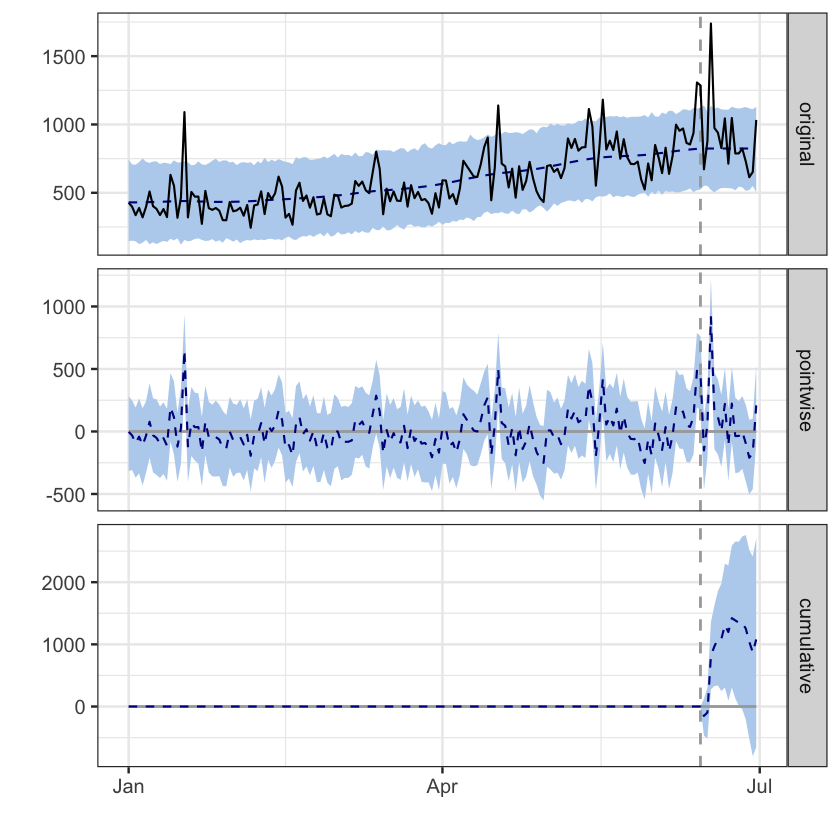

In [41]:
plot(impact)

4. В отчёте ответьте:
    - Каков абсолютный эффект (Absolute Effect)?
    - Статистически ли значим эффект? (p-value < 0.05, ДИ не включает 0)
    - Какой практический вывод для продуктовой команды?

Средняя выручка до запуска программы лояльности составляла 891 единицу. При отсутствии вмешательства следовало ожидать, что средняя выручка будет составлять 824 единицы (со стандартным отклонением 55). Таким образом, абсолютный эффект от воздействия - увеличение выручки на 67 единиц в день.

Тем не менее доверительный интервал этого значения [-41; 167] включает ноль, а p_value = 0.118 > 0.05 указывает, что влияние воздействия не является статистически значимым. Запуск программы лояльности мог иметь краткосрочный положительный эффект, но он быстро "прошел" и не оказал значимого влияния на выручку в долгосрочной перспективе. Это подвержается и графиком модели CausalImpact: нижняя граница доверительного интервала кумулятивного эффекта положительна в течение некоторого времени после воздействия, но постепенно опускается до нуля.

In [42]:
post_period_short <- c(intervention_date, as.Date("2023-06-20"))
impact <- CausalImpact(impact_xts, pre_period, post_period_short)
summary(impact)

Posterior inference {CausalImpact}

                         Average       Cumulative  
Actual                   1005          6031        
Prediction (s.d.)        824 (76)      4942 (454)  
95% CI                   [678, 968]    [4069, 5810]
                                                   
Absolute effect (s.d.)   181 (76)      1088 (454)  
95% CI                   [37, 327]     [221, 1962] 
                                                   
Relative effect (s.d.)   23% (12%)     23% (12%)   
95% CI                   [3.8%, 48%]   [3.8%, 48%] 

Posterior tail-area probability p:   0.00834
Posterior probability of an effect:  99.16567%

For more details, type: summary(impact, "report")



Действительно, при рассмотрении 5 дней после запуска программы лояльности, наблюдается статистически значимое положительное влияние на выручку (p_value = 0.005 < 0.05).

Таким образом, запуск программы лояльности целесообразен для краткосрочного повышения выручки, но не является решением, на которое можно полагаться в долгосрочной перспектике.

## Часть 2: Панельная регрессия (стратегический анализ домохозяйств)

В субботу утром, когда вы уже планировали отдых, ваш Lead внезапно выходит на связь
в рабочем чате. Краткое сообщение: «Нужно проверить общую тенденцию в потреблении кофе по домохозяйствам. Данные скину». Вы спрашиваете: «Почему задача упала
в субботу??» Лид отвечает: «Срочно нужно для стратегической сессии в понедельник.
За это — один дополнительный выходной на следующей неделе + неделю бесплатного
ланча в любой нашей кофейне». При первичном анализе присланный массив данных выглядит как лонгитюдная панель домохозяйств с переменными потребления кофе и чая
за несколько волн наблюдения. Несмотря на то, что данные слабо связаны с оперативной
аналитикой временных рядов из Части 1, вы соглашаетесь на дополнительный анализ
— бесплатный ланч звучит убедительно. . .

Вы продолжаете анализ того продукта, который выбрали в Задании 1. Если вы начинали
работать с SQLite — выбираем таблицу «panel_households»

In [43]:
households <- readr::read_csv("lab2_households.csv", show_col_types = FALSE)
print(names(households))
head(households, 5)

 [1] "id_h"    "id_w"    "region"  "popul"   "origsam" "psu"     "status" 
 [8] "site"    "e1_48a"  "e1_48c"  "e1_49a"  "e1_49c"  "f14"     "f14_0"  
[15] "f1"      "f2"      "c9_1c"   "c9_3a"   "c1_1"    "nfm"     "b1_5"   
[22] "b1_4"    "b1_8"    "d12"     "d13"     "d15"     "d16"     "e40_1"  
[29] "e40_2"   "e40_3"   "e40_5"   "e40_6"   "e37_1"   "e37_2"   "d32_6a" 
[36] "d32_7a"  "d19"     "d20"    


id_h,id_w,region,popul,origsam,psu,status,site,e1_48a,e1_48c,...,e40_2,e40_3,e40_5,e40_6,e37_1,e37_2,d32_6a,d32_7a,d19,d20
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1001,5,1,10800,1,6,3,1,2,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,1,2
1002,5,1,10800,1,6,3,1,1,2800,...,NA,NA,NA,NA,NA,NA,NA,NA,1,2
1003,5,1,10800,1,6,3,1,2,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,2,NA
1004,5,1,10800,1,6,3,1,2,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,1,2
1005,5,1,10800,1,6,3,1,2,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,1,2


### Шаг 0. Выбор зависимой переменной

- Вариант А (бинарная): e1_49a (покупка кофе за последние 7 дней: 0/1)
- Вариант Б (непрерывная): e1_49c (расходы на кофе за последние 7 дней, руб.) ИЛИ переменные e1_49b про объем потребления кофе/чая (в кг за последние 7 дней).

Аналогично для чая: e1_48a / e1_48c / e1_48b

Также посмотрите на состав предикторов, которые вам предложены к изучению указанных переменных. Не все из них необходимо исследовать — вы вправе выбрать от 4 до
6-7 тех, которые, как вам кажется, наилучшим образом могут сочетаться. Помните, что
основной контроль идет за ID д/х и номеров волны. Остальное — как в любой социологической регрессии. Помните о том, что вам необходимо работать с «полной» панелью. Для
этого постройте матрицу участия домохозяйства в лонгитюде. Если сомневаетесь, как это
можно сделать лучшим образом, попробуйте этот вариант. Затем синхронизируем через
*_join ID с переменной числа участия в мониторинге и фильтруем, чтобы участие было
в минимум 80-85% случаев (ориентир 90-100%).

In [44]:
households <- tibble(
    # ids
    household_id=households$id_h,
    wave_id=households$id_w,
    # predictors
    income=households$f14,
    savings=households$f14_0,
    needed_for_life=households$f2,
    housing=households$c1_1,
    family=households$nfm,
    # target
    target=households$e1_49a
)
head(households, 5)

household_id,wave_id,income,savings,needed_for_life,housing,family,target
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1001,5,1500000,NA,3e+06,NA,2,2
1002,5,1329000,NA,2e+06,NA,4,1
1003,5,140000,NA,1e+06,NA,1,2
1004,5,156000,NA,3e+05,NA,1,2
1005,5,670000,NA,5e+06,NA,2,2


In [45]:
participation <- summarise(
    group_by(households, household_id),
    n_waves = n_distinct(wave_id),
)
head(participation, 5)

household_id,n_waves
<dbl>,<int>
1001,2
1002,2
1003,2
1004,2
1005,1


In [46]:
households <- inner_join(households, participation, by = "household_id")
households <- filter(households, n_waves >= 0.85 * max(households$n_waves))
households <- households[ , names(households) != 'n_waves']
head(households, 5)

household_id,wave_id,income,savings,needed_for_life,housing,family,target
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10102,6,880370,NA,2e+06,NA,4,2
10108,6,782904,NA,3e+06,NA,2,2
10201,6,459000,NA,1e+06,NA,7,2
10204,6,2538000,NA,2e+06,NA,3,1
10205,6,149000,NA,2e+05,NA,1,2


In [47]:
print(dplyr::count(households, target, sort = TRUE)) # Есть странное значение 1e+08. Похоже на пропуск
households <- filter(households, target == 1 | target == 2)
households <- mutate(households, target = target - 1) # Заодно заменим 1/2  на 0/1
print(dplyr::count(households, target, sort = TRUE)) # Теперь все хорошо 
head(households, 5)

# A tibble: 3 × 2
    target     n
     <dbl> <int>
1        2  4869
2        1  1356
3 99999999     7
# A tibble: 2 × 2
  target     n
   <dbl> <int>
1      1  4869
2      0  1356


household_id,wave_id,income,savings,needed_for_life,housing,family,target
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10102,6,880370,NA,2e+06,NA,4,1
10108,6,782904,NA,3e+06,NA,2,1
10201,6,459000,NA,1e+06,NA,7,1
10204,6,2538000,NA,2e+06,NA,3,0
10205,6,149000,NA,2e+05,NA,1,1


In [48]:
print(sprintf("Number of households: %d", n_distinct(households$household_id)))
print(colSums(is.na(households)))
print(dplyr::count(households, savings, sort = TRUE)) # Тоже есть пропуски. Причем как NA, так и 99999996

[1] "Number of households: 268"
   household_id         wave_id          income         savings needed_for_life 
              0               0               0            5725            5744 
        housing          family          target 
            992               0               0 
# A tibble: 40 × 2
    savings     n
      <dbl> <int>
 1       NA  5725
 2 99999996   302
 3 99999998    39
 4     5000    20
 5 99999997    18
 6    20000    16
 7 99999999    15
 8    10000    12
 9    50000     9
10   100000     9
# ℹ 30 more rows


In [49]:
households <- mutate(
    households,
    across(where(is.character), ~na_if(.x, "NA")),
    across(where(is.numeric), ~if_else(.x %in% seq(99999990, 99999999), NA_real_, .x))
)
print(colSums(is.na(households)))

   household_id         wave_id          income         savings needed_for_life 
              0               0             213            6099            5769 
        housing          family          target 
           2055               0               0 


In [50]:
# Для анализа пропуски в целом не будут проблемой.
# Но при построении регрессии возникнут проблемы.
# Поэтому пропуски надо заполнить.
# income, savings и needed_for_life заполним так:
# - Если в соседних wave_id есть значения, то заполним средним значением по соседним волнам.
# - Если в соседних нет, но есть хотя бы в каких-то, заполним средним по всем волнам.
# - Если вообще нет данных по этому хозяйству, то заполним средним по другим хозяйствам.
# housing заполним нулями

# Здесь мне помог GPT 5.4, так как ранее я не работал на R.
# Промпт: описание, приведенное выше, и список столбцов в таблице households.

cols_with_nans = c("income", "savings", "needed_for_life")
households <- ungroup(
    mutate(
        group_by(arrange(households, household_id, wave_id), household_id),
        housing = if_else(is.na(housing), 0, housing),
        across(
            all_of(cols_with_nans), \(x) {
                x_filled <- x
                for (i in seq_along(x)) {
                    if (!is.na(x[i])) {
                      next
                    }

                    prev_val <- if (i > 1) x[i - 1] else NA
                    next_val <- if (i < length(x)) x[i + 1] else NA
                    if (!is.na(prev_val) | !is.na(next_val)) {
                        x_filled[i] <- mean(c(prev_val, next_val), na.rm = TRUE)
                    } else if (any(!is.na(x))) {
                        x_filled[i] <- mean(x, na.rm = TRUE)
                    }
                }
                x_filled
            }
        )
    )
)

for (col in cols_with_nans) {
    households[[col]][is.na(households[[col]])] <- mean(households[[col]], na.rm = TRUE)
}
print(colSums(is.na(households))) # Пропусков больше нет
head(households, 5)

   household_id         wave_id          income         savings needed_for_life 
              0               0               0               0               0 
        housing          family          target 
              0               0               0 


household_id,wave_id,income,savings,needed_for_life,housing,family,target
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10102,6,880370,50000,2000000,0,4,1
10102,7,964000,50000,3000000,0,4,1
10102,8,1700,50000,3000000,0,4,1
10102,9,2780,50000,2500000,0,4,1
10102,10,5484,50000,2500000,0,4,0


In [51]:
# Для упрощения интерпретации моделей, приведем все переменные к схожему масштабу.
# income и savings будем рассматривать в десятках тысяч рублей.
# needed_for_life и housing - в сотнях тысяч рублей.

print(colMeans(households))
print('----------------------')
households <- mutate(
    households,
    income = income / 10000,
    savings = savings / 10000,
    needed_for_life = needed_for_life / 100000,
    housing = housing / 100000
)
print(colMeans(households))

   household_id         wave_id          income         savings needed_for_life 
   7.129890e+05    2.011438e+01    8.877440e+04    3.023765e+04    2.523802e+06 
        housing          family          target 
   9.415379e+05    3.071968e+00    7.821687e-01 
[1] "----------------------"
   household_id         wave_id          income         savings needed_for_life 
   7.129890e+05    2.011438e+01    8.877440e+00    3.023765e+00    2.523802e+01 
        housing          family          target 
   9.415379e+00    3.071968e+00    7.821687e-01 


### Упражнение 2.1. Описательная статистика + TraMineR

1. Создайте объект последовательностей, например: seqdef(data[,-1], alphabet=c(0,1))

In [52]:
households_wide <- tidyr::pivot_wider(
  select(households, household_id, wave_id, target),
  names_from = wave_id,
  values_from = target
)
head(households_wide, 5)

household_id,6,7,8,9,10,11,12,13,19,...,26,27,28,29,30,31,32,33,14,18
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10102,1,1,1,1,0,0,1,1,1,...,0,0,0,0,0,0,0,0,NA,NA
10108,1,1,1,1,1,0,1,1,0,...,1,0,1,0,0,0,1,1,0,1
10111,NA,1,1,1,1,1,1,1,0,...,1,1,1,1,1,1,1,NA,1,0
10201,1,1,1,1,1,1,1,0,1,...,1,1,0,0,0,0,0,1,1,NA
10204,0,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,NA,1,NA


In [53]:
seq_obj <- TraMineR::seqdef(select(households_wide, -household_id), alphabet = c(0, 1))
head(seq_obj, 5)

 [>] found missing values ('NA') in sequence data

 [>] preparing 268 sequences

 [>] coding void elements with '%' and missing values with '*'

 [>] 2 distinct states appear in the data: 

     1 = 0

     2 = 1

 [>] state coding:

       [alphabet]  [label]  [long label] 

     1             0        00

     2             1        11

 [>] 268 sequences in the data set

 [>] min/max sequence length: 22/25



,6,7,8,9,10,11,12,13,19,20,...,26,27,28,29,30,31,32,33,14,18
,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,...,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,1,1,1,1,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,%,%
2,1,1,1,1,1,0,1,1,0,1,...,1,0,1,0,0,0,1,1,0,1
3,*,1,1,1,1,1,1,1,0,0,...,1,1,1,1,1,1,1,*,1,0
4,1,1,1,1,1,1,1,0,1,0,...,1,1,0,0,0,0,0,1,1,%
5,0,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,*,1,%



2. Визуализируйте паттерны покупок по волнам:
    - seqIplot() + seqiplot() — индексный график
    - seqdplot() — распределение по состояниям

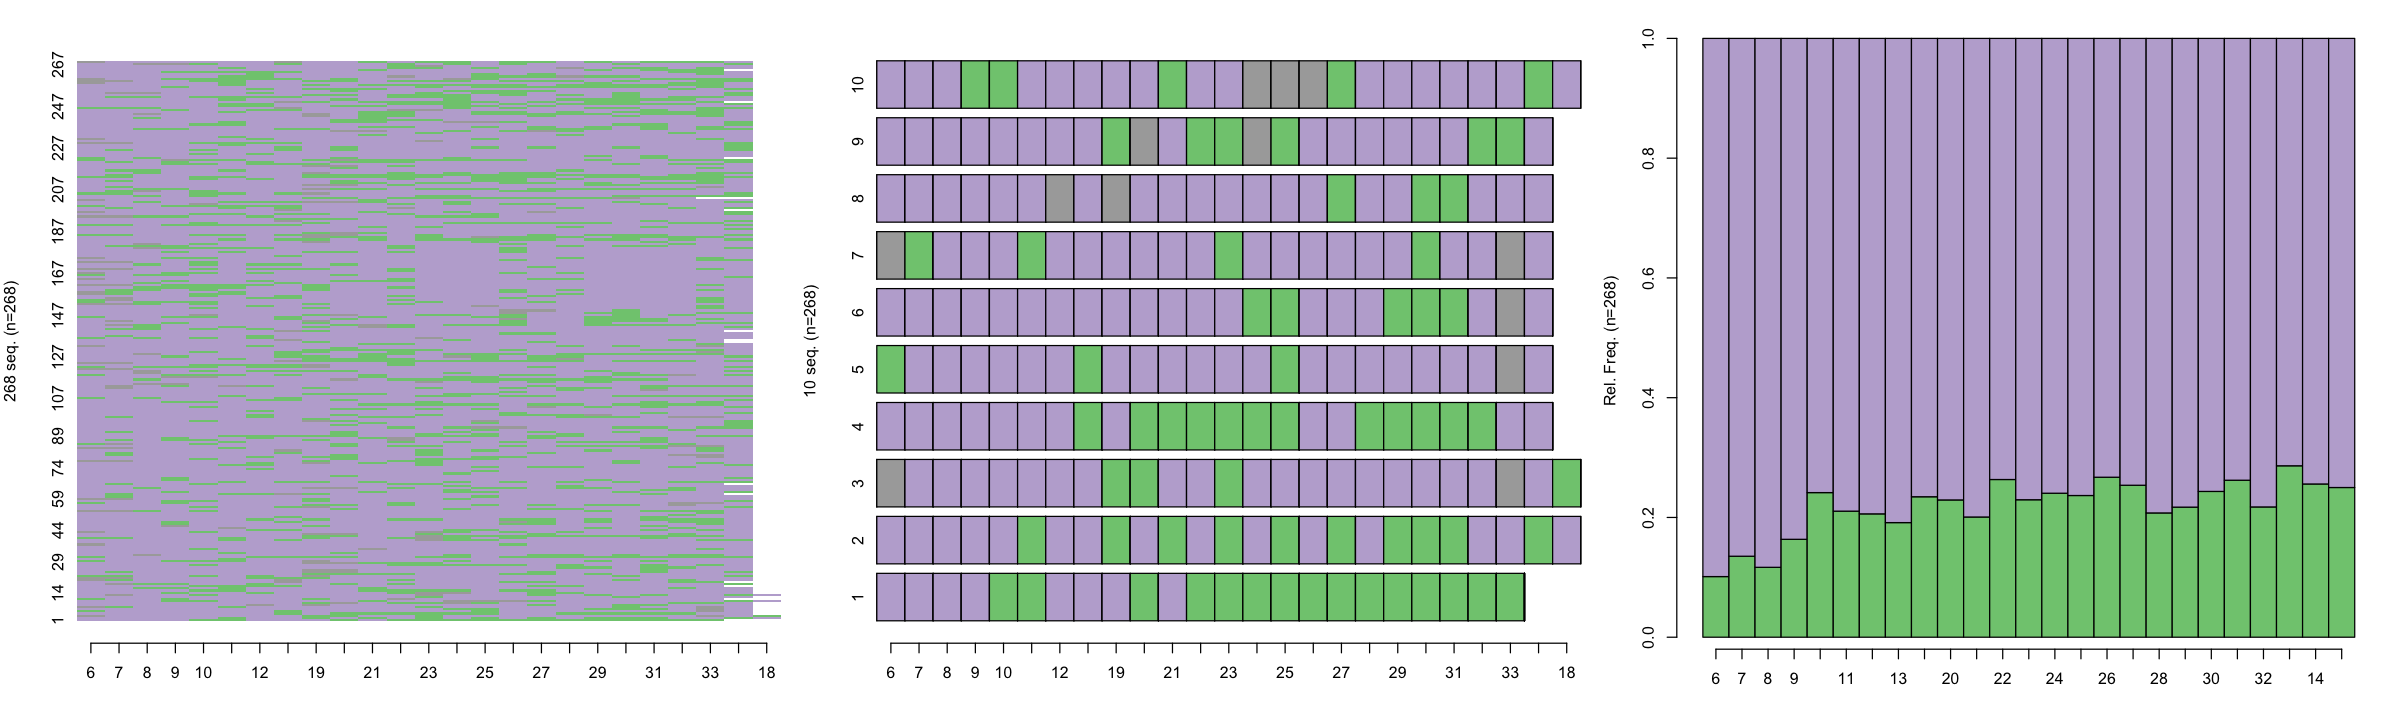

In [54]:
old_opts <- options(repr.plot.width = 20, repr.plot.height = 6)

layout(matrix(1:3, 1, 3))
par(mar = c(4, 4, 2, 1), cex = 0.8)

TraMineR::seqIplot(seq_obj, with.legend = FALSE, use.layout = FALSE)
TraMineR::seqiplot(seq_obj, with.legend = FALSE, use.layout = FALSE)
TraMineR::seqdplot(seq_obj, with.legend = TRUE,  use.layout = FALSE)

options(old_opts)   # restore previous option values

Постройте дополнительно графики в разрезе какой-то одной (двух) функциональных групп.


In [55]:
household_stats = summarise(
    group_by(households, household_id),
    total_income = sum(income, na.rm = TRUE),
    avg_needed_for_life = mean(needed_for_life, na.rm = TRUE)
)
household_stats <- mutate(
    household_stats,
    total_income_group = cut(
        total_income,
        breaks = quantile(total_income, probs = c(0, 0.25, 0.5, 0.75, 1), na.rm = TRUE),
        include.lowest = TRUE,
        labels = c("low", "below average", "above average", "high")
    ),
    avg_needed_for_life_group = cut(
        avg_needed_for_life,
        breaks = quantile(avg_needed_for_life, probs = c(0, 0.25, 0.5, 0.75, 1), na.rm = TRUE),
        include.lowest = TRUE,
        labels = c("low", "below average", "above average", "high")
    )
)
households_wide_with_groups <-inner_join(households_wide, household_stats, by = "household_id")
head(households_wide_with_groups, 5)

household_id,6,7,8,9,10,11,12,13,19,...,30,31,32,33,14,18,total_income,avg_needed_for_life,total_income_group,avg_needed_for_life_group
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
10102,1,1,1,1,0,0,1,1,1,...,0,0,0,0,NA,NA,291.76620,25.21739,high,above average
10108,1,1,1,1,1,0,1,1,0,...,0,0,1,1,0,1,291.16770,24.80000,high,above average
10111,NA,1,1,1,1,1,1,1,0,...,1,1,1,NA,1,0,87.13432,8.00000,low,low
10201,1,1,1,1,1,1,1,0,1,...,0,0,0,1,1,NA,162.43830,10.00000,below average,low
10204,0,1,1,1,1,1,1,0,1,...,1,1,1,NA,1,NA,500.68750,22.60870,high,above average


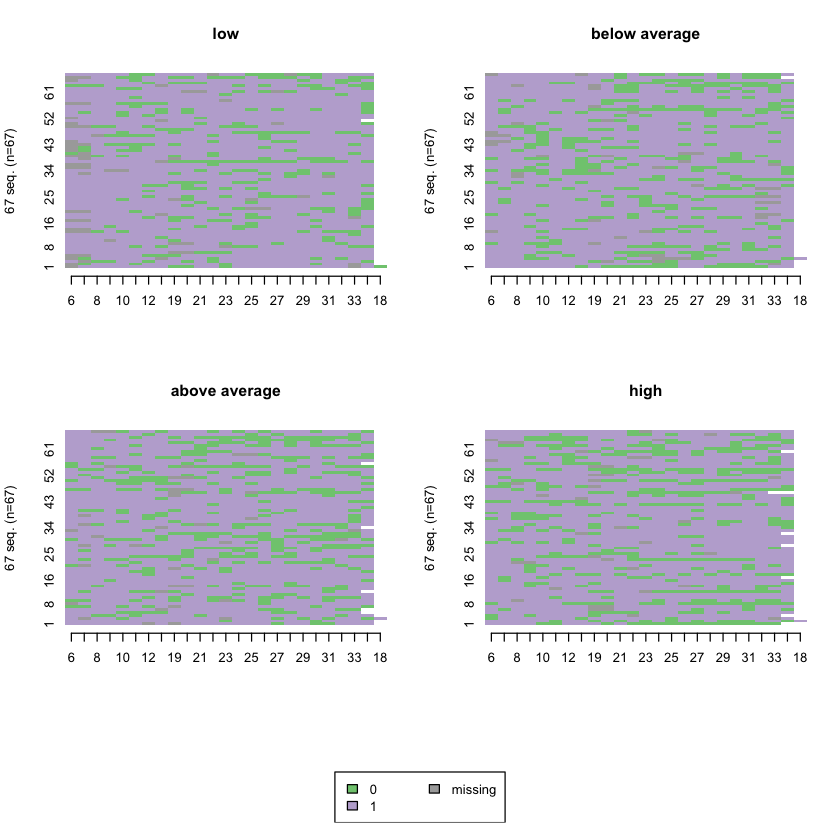

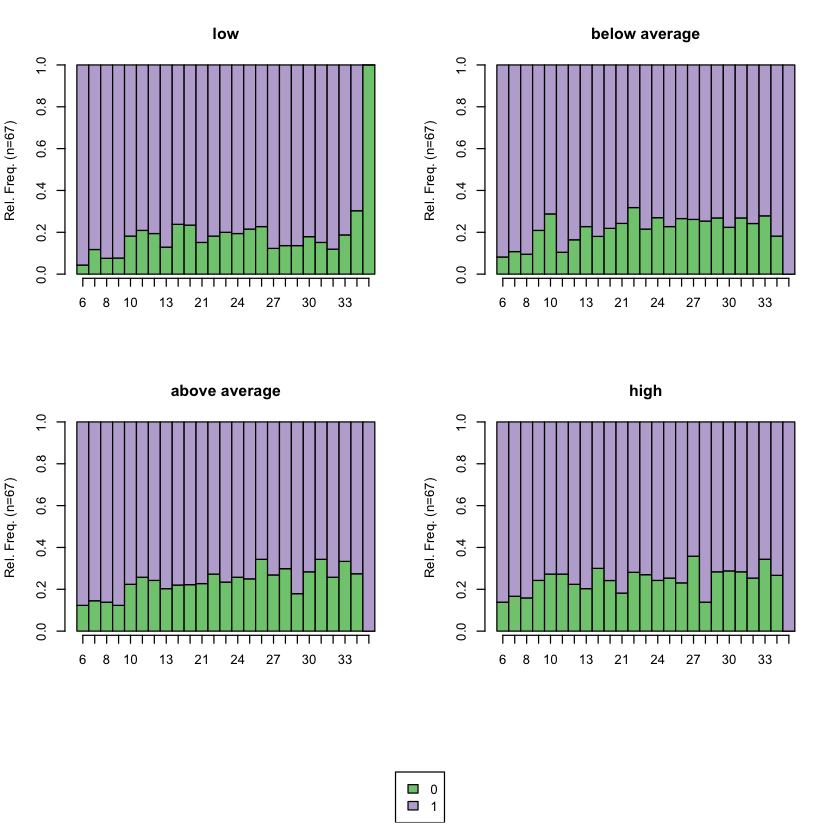

In [56]:
TraMineR::seqIplot(seq_obj, group = households_wide_with_groups$total_income_group, with.legend = TRUE)
TraMineR::seqdplot(seq_obj, group = households_wide_with_groups$total_income_group, with.legend = TRUE)

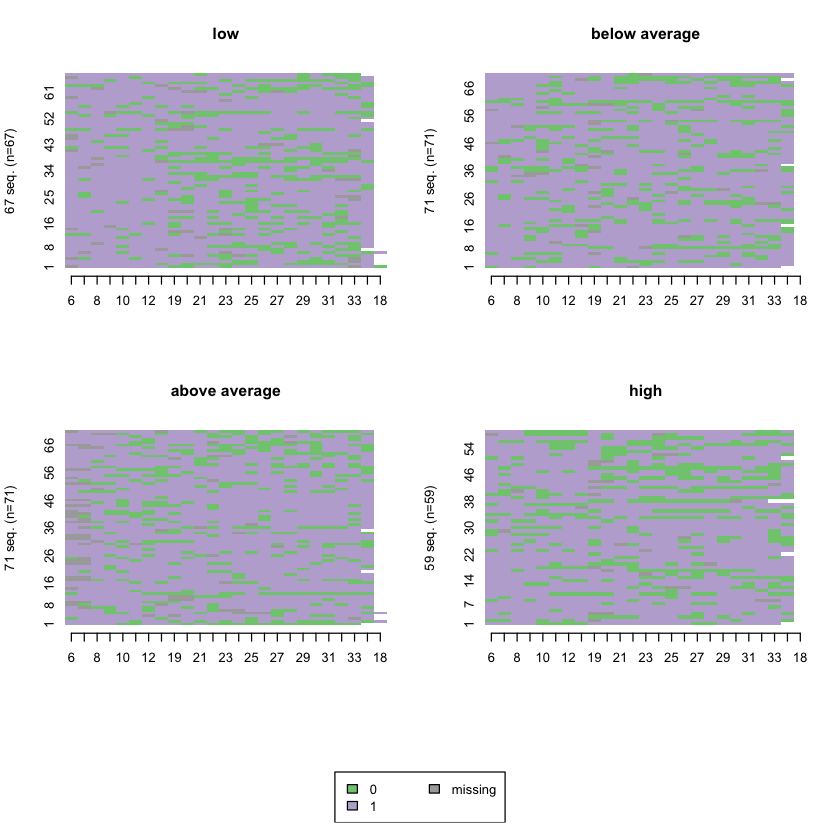

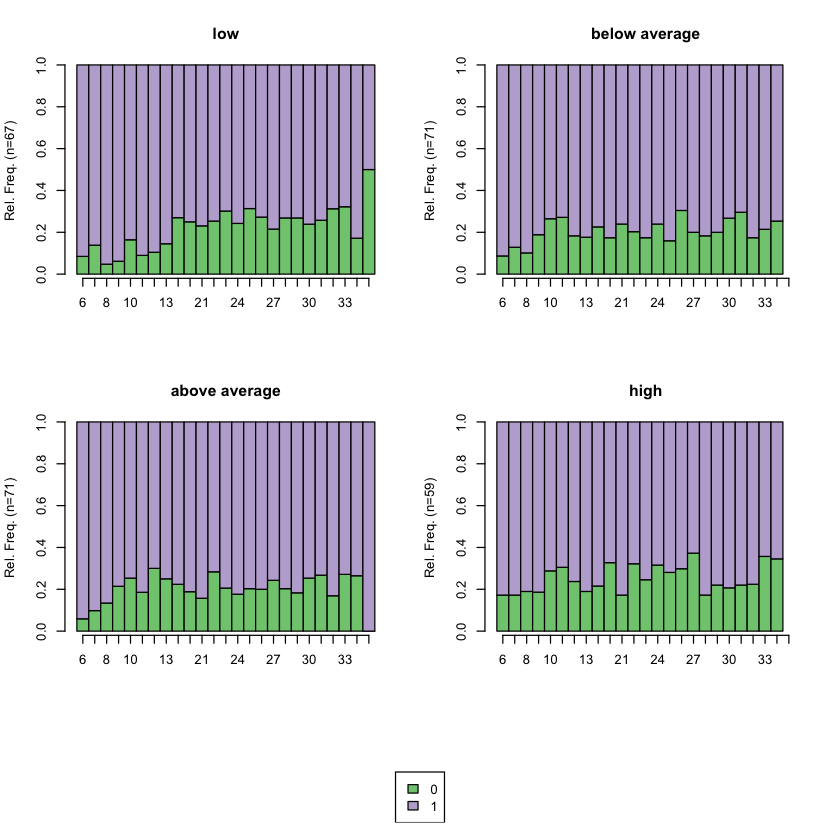

In [57]:
TraMineR::seqIplot(seq_obj, group = households_wide_with_groups$avg_needed_for_life_group, with.legend = TRUE)
TraMineR::seqdplot(seq_obj, group = households_wide_with_groups$avg_needed_for_life_group, with.legend = TRUE)


3. В отчёте ответьте:
    - Растёт или падает доля покупающих кофе/чай со временем?
    - Есть ли устойчивые паттерны (всегда покупают / никогда / переключаются)?
    - Как это соотносится с гипотезой о «кофе/чай как нормальном товаре»?

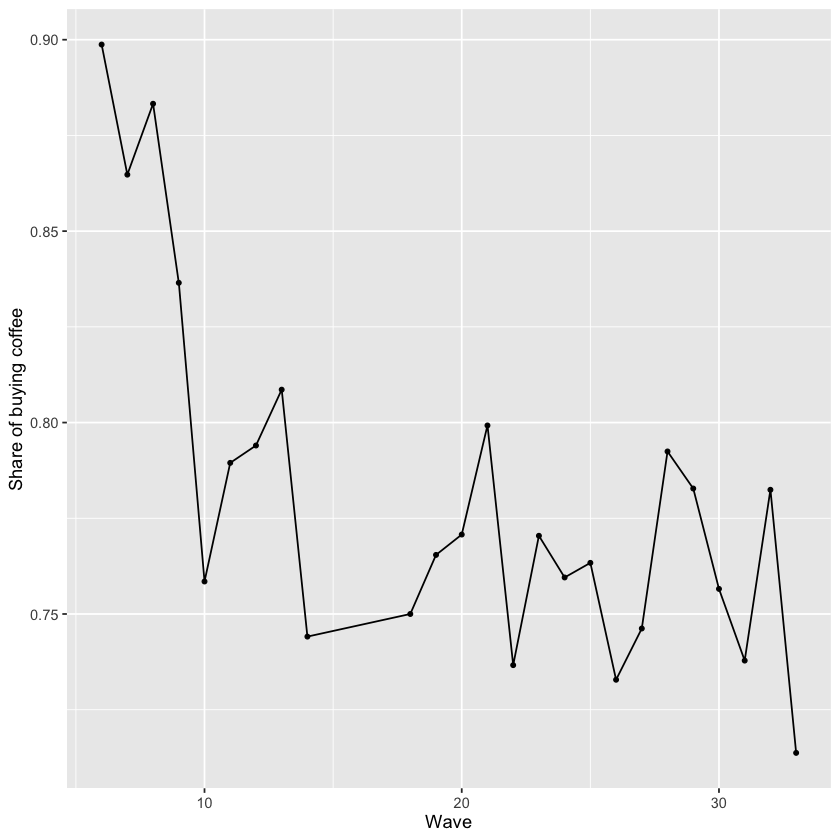

In [58]:
share = summarise(group_by(households, wave_id), share = mean(target))
(
    ggplot(share, aes(x = wave_id, y = share)) +
    geom_line() + geom_point(size = 1) +
    labs(x = "Wave", y = "Share of buying coffee")
)

Доля покупающих кофе со временем падает: с почти 90% на 6 волне до чуть более 70% на 33 волне.

Явных устойчивых паттернов не наблюдается. Некоторые хозяйства покупают кофе регулярно, некоторые часто переключаются, а некоторые вовсе купили кофе всего несколько раз за период наблюдения.

Рассматривая данные в разрезе по уровню дохода, можно предположить, что хозяйства с большим доходом покупают кофе чаще. Тем не менее разница недостаточно велика, чтобы утверждать наличие такой закономерности только по графикам; требуется дополнительная проверка статистической значимости наблюдаемых различий. Таким образом, результаты в целом соотносятся с гипотезом о "кофе как нормальном товаре", но требуется дополнительная проверка статистических гипотез. Предварительно кажется более вероятным, что спрос на кофе не зависит или зависит незначительно от уровня дохода.

### Упражнение 2.2. Базовая логистическая/линейная модель

1. Оцените модель без учёта панельной структуры:
2. Рассчитайте Odds Ratio (для логита) ЛИБО AME (намного лучше для логита и непрерывной).

In [59]:
glm_logit <- glm(
    target ~ income + savings + needed_for_life + housing + family,
    data = households,
    family = binomial
)
summary(glm_logit)


Call:
glm(formula = target ~ income + savings + needed_for_life + housing + 
    family, family = binomial, data = households)

Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)      1.6961092  0.0782356  21.680  < 2e-16 ***
income           0.0012550  0.0012155   1.032 0.301855    
savings         -0.0269676  0.0110508  -2.440 0.014674 *  
needed_for_life  0.0002659  0.0011606   0.229 0.818794    
housing         -0.0085207  0.0022104  -3.855 0.000116 ***
family          -0.0851693  0.0170436  -4.997 5.82e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 6525.7  on 6224  degrees of freedom
Residual deviance: 6474.7  on 6219  degrees of freedom
AIC: 6486.7

Number of Fisher Scoring iterations: 4


In [60]:
or <- exp(coef(glm_logit))
or_ci <- exp(confint(glm_logit))
tibble(term = names(or), OR = unname(or), CI_low = or_ci[, 1], CI_high = or_ci[, 2])

Waiting for profiling to be done...



term,OR,CI_low,CI_high
<chr>,<dbl>,<dbl>,<dbl>
(Intercept),5.4526905,4.6783767,6.3581866
income,1.0012558,0.9989962,1.0037923
savings,0.9733927,0.9527699,0.9950900
needed_for_life,1.0002659,0.9980835,1.0026562
housing,0.9915155,0.9872575,0.9958552
family,0.9183568,0.8882925,0.9496974



3. В отчёте ответьте:
    - Какие предикторы значимы (p < 0.05)?
    - Интерпретируйте коэффициент при f14 (доход)
    - Соответствует ли знак эффекта гипотезе («кофе — нормальный товар»)?
    
Пример интерпретации (очень примерный, но может быть полезным):
«Odds Ratio для f14 = 1.03 [95% ДИ: 1.01–1.05] означает: увеличение дохода на
10 000 руб. связано с ростом шансов покупки кофе на 3%. Это подтверждает
гипотезу о кофе как о нормальном товаре.»

Значимые предикторы: savings, housing и family. Коэффициент при f14 (переименован в income) не превышает 1.002 при 95% доверительном интервале [0.9989, 1.0037], что означает увеличение шанса покупки кофе на 0.2% при увеличении дохода на 10000 руб. Этот эффект соответствует гипотезе о том, что кофе - нормальный товар. Тем не менее результат не является статистически значимым.

### Упражнение 2.3. Панельная модель: GEE или FE/RE

1. Оцените модель с учётом панельной структуры:
2. Обоснуйте выбор метода (GEE / FE / RE)
3. Сравните результаты с Упражнением 2.2 (изменилась ли значимость предикторов?)

In [61]:
gee_logit <- geeglm(
    target ~ income + savings + needed_for_life + housing + family,
    data = households,
    family = binomial(link = "logit"),
    id = household_id,
    corstr = "exchangeable"
)
summary(gee_logit)


Call:
geeglm(formula = target ~ income + savings + needed_for_life + 
    housing + family, family = binomial(link = "logit"), data = households, 
    id = household_id, corstr = "exchangeable")

 Coefficients:
                  Estimate    Std.err    Wald Pr(>|W|)    
(Intercept)      1.7692079  0.1187761 221.871  < 2e-16 ***
income           0.0018719  0.0015017   1.554 0.212564    
savings         -0.0310432  0.0127355   5.942 0.014788 *  
needed_for_life  0.0003034  0.0017835   0.029 0.864902    
housing         -0.0084802  0.0034434   6.065 0.013789 *  
family          -0.1078178  0.0278020  15.039 0.000105 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation structure = exchangeable 
Estimated Scale Parameters:

            Estimate Std.err
(Intercept)   0.9998 0.04463
  Link = identity 

Estimated Correlation Parameters:
      Estimate Std.err
alpha  0.09107 0.01366
Number of clusters:   268  Maximum cluster size: 25 

In [62]:
gee_coef <- summary(gee_logit)$coefficients
tibble(
    term = rownames(gee_coef),
    OR = exp(gee_coef[, 1]),
    CI_low = exp(gee_coef[, 1] - 1.96 * gee_coef[, 2]),
    CI_high = exp(gee_coef[, 1] + 1.96 * gee_coef[, 2])
)

term,OR,CI_low,CI_high
<chr>,<dbl>,<dbl>,<dbl>
(Intercept),5.8662,4.6479,7.4039
income,1.0019,0.9989,1.0048
savings,0.9694,0.9455,0.9939
needed_for_life,1.0003,0.9968,1.0038
housing,0.9916,0.9849,0.9983
family,0.8978,0.8502,0.9481


Для нашей задачи целесообразно использовать GEE: это наиболее подходящая модель для анализа лонгитюдных данных с точки зрения общих эффектов, наблюдаемых у всех пользователей. FE/RE, напротив, направлены на анализ индивидуальных закономерностей, специфичных для отдельных пользователей - это не то, что нам нужно. Более того, GEE лучше подходит для предсказания бинарной переменной - как в нашей задаче.

Результаты в целом соответствуют полученным ранее. Наибоеле значимым предикторами таккже оказались savings, housing и family, а коэффициент при income укаызывает, что при увеличении дохода на 10000 руб. шанс покупки кофе увеличивается на 0.019% (хотя влияние и не является значимым).

### Упражнение 2.4. Интерпретация + продуктовый вывод

1. Сформулируйте рекомендацию для продуктовой команды на основе результатов (3–4
предложения)
2. В отчёте напишите:
    - Для какой группы домохозяйств кофе[чай] — приоритетный продукт?
    - Какой канал коммуникации/продвижения либо социальный паттерн может быть эффективен?
    - Как эти инсайты могут дополнить оперативную аналитику из Части 1?

Пример вывода (очень примерный, но может быть полезным):
«Модель показывает, что домохозяйства с доходом выше 80 000 руб. и долей
высшего образования >50% имеют вероятность покупки кофе на 25 п.п. выше
среднего. Рекомендация: для таргетированной рекламы премиум-линеек кофе
использовать аудиторию городских жителей 25–45 лет с высшим образованием. Эти инсайты дополняют оперативную аналитику (Часть 1), объясняя,
кто формирует спрос, а не только когда он растёт.»

Результаты указывают, что кофе покупают в основном домохозяйства с меньшим размером семьи, меньшими сбережениями и низкой стоимостью аренды жилья (наиболее устойчивые и статистически значимые предикторы). Хотя уровень дохода прямо пропорционален вероятности покупки кофе, эта зависимость минимальна и статистически незначима, поэтому принимать продуктовые решения на основании этого не стоит. Стратегию развития следует строить не по доходу потребителей, а вокруг компактных домохозяйств и сценариев посведневного потребления: удобный формат покупки, регулярные акции и т.д. Эти выводы дополняют оперативную аналитику из Части 1, показывая не только моменты роста спроса, но и его причины, какие сегменты потребителей его формируют.